<a href="https://colab.research.google.com/github/vaishnavidangi704-commits/CSL701-11_Machine-Learning-Lab/blob/main/Experiments%20and%20Mini-Project/ML_Experiment_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Aim

To implement Support Vector Machine (SVM) for classification of the Iris dataset and visualize its decision boundary and compare it with a normal linear classification boundary.

## Objectives

1. To understand the concept of Support Vector Machine.
2. To implement SVM using Python.
3. To visualize the SVM decision boundary.
4. To identify the support vectors.
5. To compare the SVM boundary with a normal linear classification boundary.
6. To evaluate the performance of the classifiers.

# Relevant Theory

### Support Vector Machine

Support Vector Machine (SVM) is a supervised machine learning algorithm used for classification.

SVM finds a decision boundary that separates different classes while trying to maximize the distance, called the **margin**, between the classes.

The points closest to the decision boundary are called **support vectors**.

For a linear SVM, the decision boundary can be represented as:

$$
w^T x + b = 0
$$

where:

- $w$ = weight vector
- $x$ = input features
- $b$ = bias


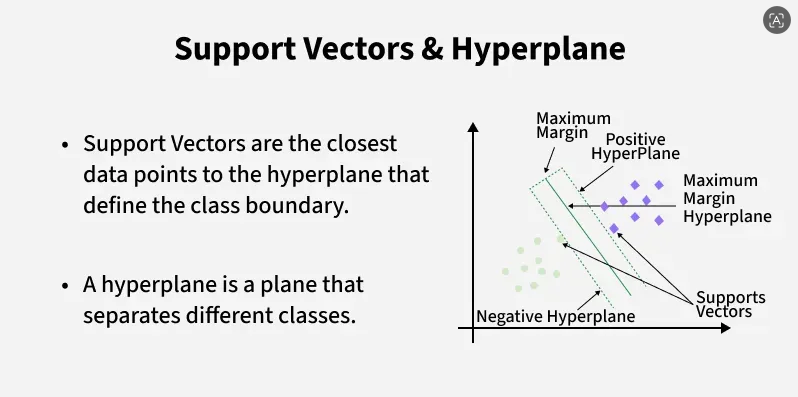
### Kernel

SVM can use different kernels to create decision boundaries.

Common kernels are:

- Linear
- Polynomial
- RBF
- Sigmoid

In this experiment, we mainly use the **Linear SVM** and **RBF SVM**.

---

# Dataset Information

Get the IRIS dataset from Kaggle using below link

https://www.kaggle.com/datasets/uciml/iris

The Iris dataset contains measurements of Iris flowers belonging to three classes:

- Iris-setosa
- Iris-versicolor
- Iris-virginica

The four features are:

- Sepal Length
- Sepal Width
- Petal Length
- Petal Width

For visualization, we will use:

**Petal Length and Petal Width.**

# Task 1: Import Libraries and Load Dataset

Load the Iris dataset.

---

In [4]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

# Load Iris dataset
# Upload Iris.csv to Colab before running this cell
df = pd.read_csv('/content/Iris.csv')

# Display first 5 rows
df.head()



,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


# Task 2: Explore the Dataset

In [5]:
# Display dataset information
print("Dataset Shape:", df.shape)

print("\nDataset Information:")
df.info()

print("\nFirst 5 Rows:")
display(df.head())

print("\nStatistical Summary:")
display(df.describe())

print("\nColumn Names:")
print(df.columns)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nClass Distribution:")
print(df['Species'].value_counts())


Dataset Shape: (150, 6)

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB

First 5 Rows:


,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa



Statistical Summary:


,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,75.500000,5.843333,3.054000,3.758667,1.198667
std,43.445368,0.828066,0.433594,1.764420,0.763161
min,1.000000,4.300000,2.000000,1.000000,0.100000
25%,38.250000,5.100000,2.800000,1.600000,0.300000
50%,75.500000,5.800000,3.000000,4.350000,1.300000
75%,112.750000,6.400000,3.300000,5.100000,1.800000
max,150.000000,7.900000,4.400000,6.900000,2.500000



Column Names:
Index(['Id', 'SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm',
       'Species'],
      dtype='object')

Missing Values:
Id               0
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64

Class Distribution:
Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64


# Task 3: Select Features and Target

Remove the `Id` column.

Select Remaining Features

In [6]:
# Remove Id column
df = df.drop('Id', axis=1)

# Select features
X = df.drop('Species', axis=1)

# Select target
y = df['Species']

print("Features:")
display(X.head())

print("\nTarget:")
display(y.head())

print("\nFeature Shape:", X.shape)
print("Target Shape:", y.shape)


Features:


,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2



Target:


,Species
0,Iris-setosa
1,Iris-setosa
2,Iris-setosa
3,Iris-setosa
4,Iris-setosa



Feature Shape: (150, 4)
Target Shape: (150,)


# Task 4: Split and Scale the Data

Divide the dataset into training and testing sets.

In [7]:
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Create StandardScaler
scaler = StandardScaler()

# Fit scaler on training data and transform training data
X_train_scaled = scaler.fit_transform(X_train)

# Transform testing data
X_test_scaled = scaler.transform(X_test)

print("Training data shape:", X_train_scaled.shape)
print("Testing data shape:", X_test_scaled.shape)


Training data shape: (120, 4)
Testing data shape: (30, 4)


# Task 5: Implement Linear SVM

Create an SVM model using a **linear kernel**.

Make predictions.

In [8]:
# Create Linear SVM model
svm_model = SVC(kernel='linear', random_state=42)

# Train the model
svm_model.fit(X_train_scaled, y_train)

# Make predictions
y_pred_svm = svm_model.predict(X_test_scaled)

print("Predicted Classes:")
print(y_pred_svm)


Predicted Classes:
['Iris-setosa' 'Iris-virginica' 'Iris-versicolor' 'Iris-versicolor'
 'Iris-setosa' 'Iris-versicolor' 'Iris-setosa' 'Iris-setosa'
 'Iris-virginica' 'Iris-versicolor' 'Iris-virginica' 'Iris-virginica'
 'Iris-virginica' 'Iris-versicolor' 'Iris-setosa' 'Iris-setosa'
 'Iris-setosa' 'Iris-versicolor' 'Iris-versicolor' 'Iris-virginica'
 'Iris-setosa' 'Iris-virginica' 'Iris-versicolor' 'Iris-virginica'
 'Iris-virginica' 'Iris-versicolor' 'Iris-versicolor' 'Iris-setosa'
 'Iris-virginica' 'Iris-setosa']


# Task 6: Evaluate SVM

### Calculate Accuracy

Calculate the accuracy of the SVM model.

### Confusion Matrix

Generate the confusion matrix to evaluate the classification results.

### Classification Report

Generate the classification report containing:

- Precision
- Recall
- F1-Score
- Support

---


In [9]:
# Calculate accuracy
svm_accuracy = accuracy_score(y_test, y_pred_svm)

print("Linear SVM Accuracy:", svm_accuracy)
print("Linear SVM Accuracy: {:.2f}%".format(svm_accuracy * 100))


Linear SVM Accuracy: 1.0
Linear SVM Accuracy: 100.00%


Confusion Matrix:
[[10  0  0]
 [ 0 10  0]
 [ 0  0 10]]


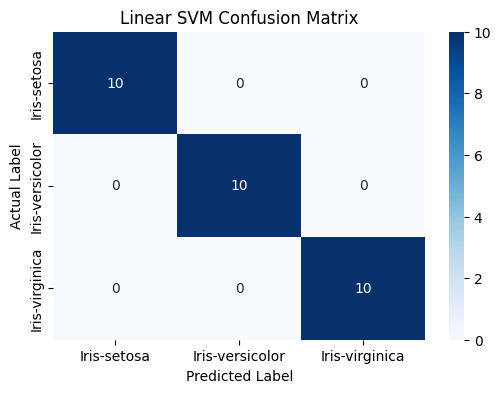

In [10]:
# Generate confusion matrix
cm_svm = confusion_matrix(y_test, y_pred_svm)

print("Confusion Matrix:")
print(cm_svm)

# Visualize confusion matrix
plt.figure(figsize=(6, 4))

sns.heatmap(
    cm_svm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=svm_model.classes_,
    yticklabels=svm_model.classes_
)

plt.title('Linear SVM Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.show()


In [11]:
# Generate classification report
print("Linear SVM Classification Report:")
print(classification_report(y_test, y_pred_svm))


Linear SVM Classification Report:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      1.00      1.00        10
 Iris-virginica       1.00      1.00      1.00        10

       accuracy                           1.00        30
      macro avg       1.00      1.00      1.00        30
   weighted avg       1.00      1.00      1.00        30



# Task 7: Visualize SVM Decision Boundary

For visualization, we use only two features:

- Petal Length
- Petal Width

### Create the 2-D Dataset

Select **Petal Length** and **Petal Width** as the input features.

### Split the Data

Divide the 2-D dataset into training and testing sets.

### Scale the Data

Standardize the selected features before training the SVM model.

### Train SVM

Train an SVM classifier using a **linear kernel**.

### Plot Decision Boundary

Visualize the SVM decision boundary along with the data points.

---

In [12]:
# Select two features
X_2d = df[['PetalLengthCm', 'PetalWidthCm']]
y_2d = df['Species']

# Split the 2-D data
X2_train, X2_test, y2_train, y2_test = train_test_split(
    X_2d,
    y_2d,
    test_size=0.2,
    random_state=42,
    stratify=y_2d
)

# Scale the 2-D features
scaler_2d = StandardScaler()

X2_train_scaled = scaler_2d.fit_transform(X2_train)
X2_test_scaled = scaler_2d.transform(X2_test)

# Train Linear SVM
svm_2d = SVC(kernel='linear', random_state=42)
svm_2d.fit(X2_train_scaled, y2_train)

# Accuracy
y2_pred_svm = svm_2d.predict(X2_test_scaled)

print("2-D Linear SVM Accuracy:",
      accuracy_score(y2_test, y2_pred_svm))


2-D Linear SVM Accuracy: 0.9333333333333333


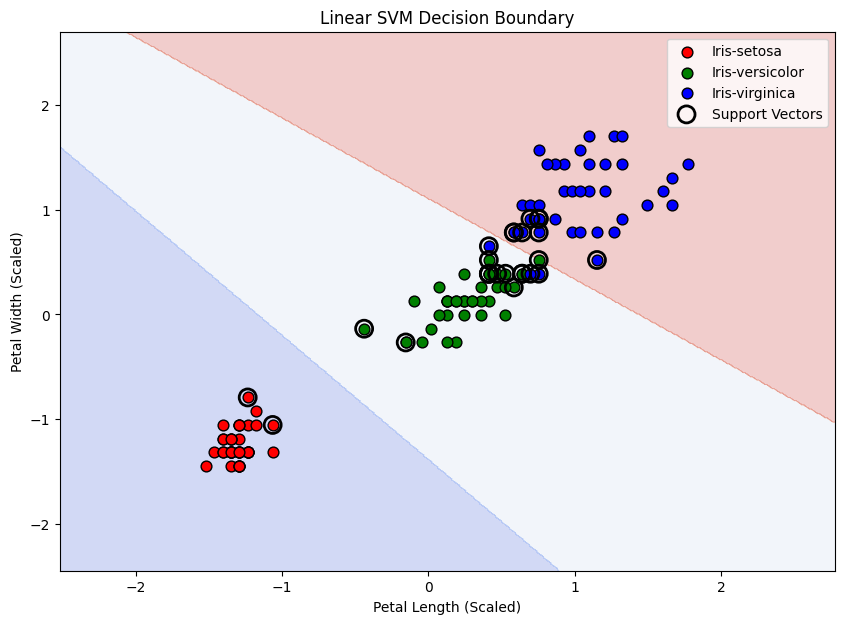

In [13]:
# Create mesh grid
x_min = X2_train_scaled[:, 0].min() - 1
x_max = X2_train_scaled[:, 0].max() + 1
y_min = X2_train_scaled[:, 1].min() - 1
y_max = X2_train_scaled[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 500),
    np.linspace(y_min, y_max, 500)
)

# Predict for every point in the mesh
Z = svm_2d.predict(np.c_[xx.ravel(), yy.ravel()])

# Convert predictions to numerical values
class_names = svm_2d.classes_
Z_numeric = np.array([
    np.where(class_names == label)[0][0]
    for label in Z
])

Z_numeric = Z_numeric.reshape(xx.shape)

# Plot decision regions
plt.figure(figsize=(10, 7))

plt.contourf(
    xx,
    yy,
    Z_numeric,
    alpha=0.25,
    cmap=plt.cm.coolwarm
)

# Plot training points
colors = ['red', 'green', 'blue']

for i, class_name in enumerate(class_names):
    indices = y2_train == class_name

    plt.scatter(
        X2_train_scaled[indices, 0],
        X2_train_scaled[indices, 1],
        label=class_name,
        color=colors[i],
        edgecolor='black',
        s=60
    )

# Plot support vectors
plt.scatter(
    svm_2d.support_vectors_[:, 0],
    svm_2d.support_vectors_[:, 1],
    s=150,
    facecolors='none',
    edgecolors='black',
    linewidths=2,
    label='Support Vectors'
)

plt.xlabel('Petal Length (Scaled)')
plt.ylabel('Petal Width (Scaled)')
plt.title('Linear SVM Decision Boundary')
plt.legend()
plt.show()


In [14]:
print("Number of Support Vectors for each class:")
print(svm_2d.n_support_)

print("\nTotal Support Vectors:")
print(len(svm_2d.support_vectors_))

print("\nSupport Vector Points:")
print(svm_2d.support_vectors_)


Number of Support Vectors for each class:
[ 2 13 10]

Total Support Vectors:
25

Support Vector Points:
[[-1.23340162 -0.79429223]
 [-1.06295073 -1.05723035]
 [ 0.58474127  0.25746024]
 [ 0.41429037  0.3889293 ]
 [ 0.64155823  0.3889293 ]
 [-0.15387928 -0.268416  ]
 [ 0.58474127  0.78333648]
 [ 0.75519216  0.52039836]
 [ 0.41429037  0.3889293 ]
 [ 0.47110734  0.3889293 ]
 [ 0.41429037  0.52039836]
 [ 0.41429037  0.3889293 ]
 [-0.43796411 -0.13694694]
 [ 0.5279243   0.3889293 ]
 [ 0.64155823  0.3889293 ]
 [ 0.41429037  0.65186742]
 [ 0.6983752   0.91480554]
 [ 0.75519216  0.3889293 ]
 [ 0.75519216  0.91480554]
 [ 0.75519216  0.78333648]
 [ 0.75519216  0.91480554]
 [ 0.6983752   0.3889293 ]
 [ 1.15291092  0.52039836]
 [ 0.64155823  0.78333648]
 [ 0.58474127  0.78333648]]


# Task 8: Normal Linear Classification Boundary

For comparison, we use **Logistic Regression** as a normal linear classifier.

Train a Logistic Regression model using the same two features and visualize its decision boundary.

---

In [15]:
# Train Logistic Regression using the same 2-D scaled data
logistic_model = LogisticRegression(
    max_iter=200,
    random_state=42
)

logistic_model.fit(X2_train_scaled, y2_train)

# Make predictions
y2_pred_logistic = logistic_model.predict(X2_test_scaled)

# Calculate accuracy
logistic_accuracy = accuracy_score(
    y2_test,
    y2_pred_logistic
)

print("Logistic Regression Accuracy:",
      logistic_accuracy)

print("Logistic Regression Accuracy: {:.2f}%".format(
    logistic_accuracy * 100
))


Logistic Regression Accuracy: 0.9333333333333333
Logistic Regression Accuracy: 93.33%


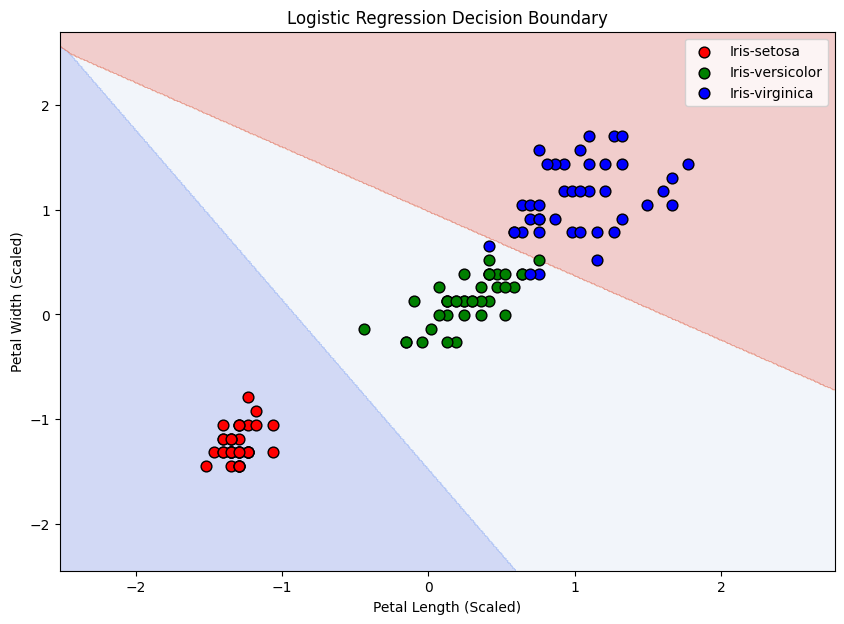

In [16]:
# Predict mesh grid points using Logistic Regression
Z_logistic = logistic_model.predict(
    np.c_[xx.ravel(), yy.ravel()]
)

# Convert class labels to numbers
Z_logistic_numeric = np.array([
    np.where(class_names == label)[0][0]
    for label in Z_logistic
])

Z_logistic_numeric = Z_logistic_numeric.reshape(xx.shape)

# Plot
plt.figure(figsize=(10, 7))

plt.contourf(
    xx,
    yy,
    Z_logistic_numeric,
    alpha=0.25,
    cmap=plt.cm.coolwarm
)

# Plot training data
for i, class_name in enumerate(class_names):
    indices = y2_train == class_name

    plt.scatter(
        X2_train_scaled[indices, 0],
        X2_train_scaled[indices, 1],
        label=class_name,
        color=colors[i],
        edgecolor='black',
        s=60
    )

plt.xlabel('Petal Length (Scaled)')
plt.ylabel('Petal Width (Scaled)')
plt.title('Logistic Regression Decision Boundary')
plt.legend()
plt.show()


# Task 9: Compare SVM and Normal Boundary

Plot both the **SVM** and **Logistic Regression** decision boundaries on the same graph.

Compare how the two classifiers separate the different classes.

---

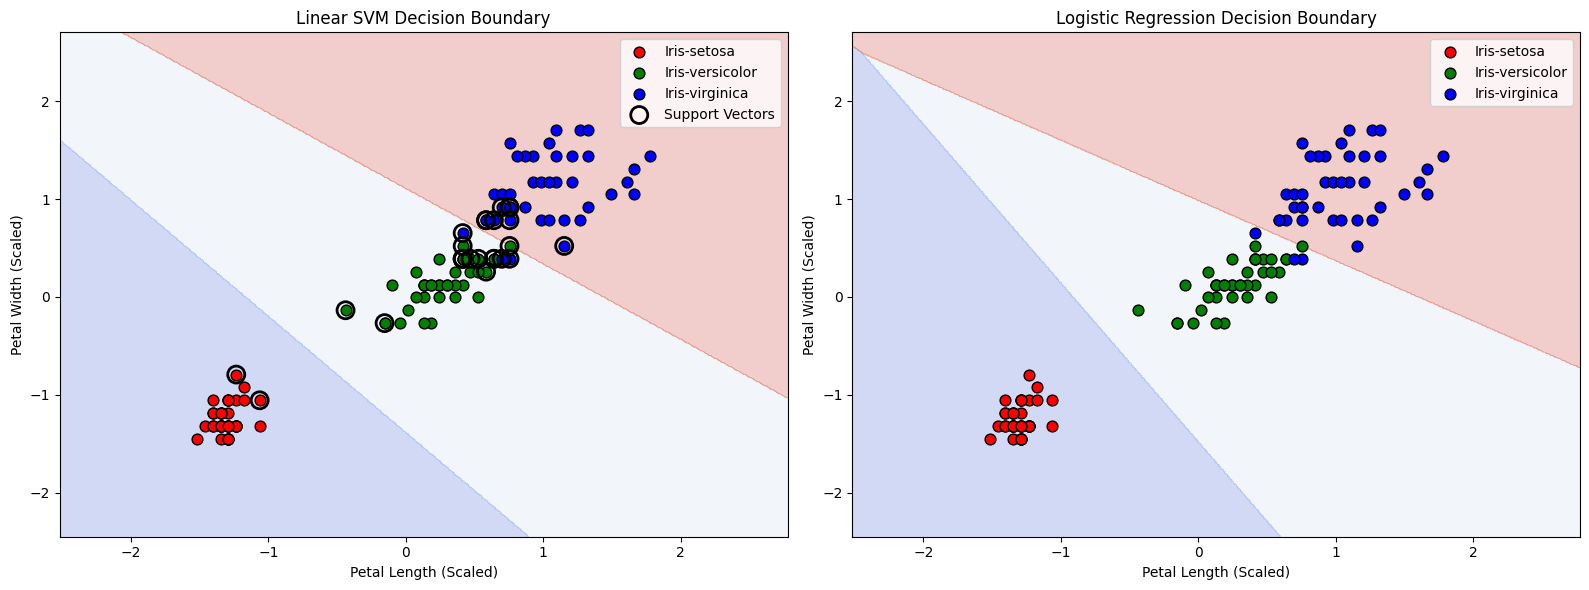

In [17]:
# Create predictions for mesh grid
Z_svm = svm_2d.predict(np.c_[xx.ravel(), yy.ravel()])
Z_lr = logistic_model.predict(np.c_[xx.ravel(), yy.ravel()])

# Convert labels to numbers
Z_svm_num = np.array([
    np.where(class_names == label)[0][0]
    for label in Z_svm
]).reshape(xx.shape)

Z_lr_num = np.array([
    np.where(class_names == label)[0][0]
    for label in Z_lr
]).reshape(xx.shape)

# Create side-by-side comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ---------------- SVM ----------------
axes[0].contourf(
    xx,
    yy,
    Z_svm_num,
    alpha=0.25,
    cmap=plt.cm.coolwarm
)

for i, class_name in enumerate(class_names):
    indices = y2_train == class_name

    axes[0].scatter(
        X2_train_scaled[indices, 0],
        X2_train_scaled[indices, 1],
        color=colors[i],
        label=class_name,
        edgecolor='black',
        s=60
    )

# Support vectors
axes[0].scatter(
    svm_2d.support_vectors_[:, 0],
    svm_2d.support_vectors_[:, 1],
    s=150,
    facecolors='none',
    edgecolors='black',
    linewidths=2,
    label='Support Vectors'
)

axes[0].set_title('Linear SVM Decision Boundary')
axes[0].set_xlabel('Petal Length (Scaled)')
axes[0].set_ylabel('Petal Width (Scaled)')
axes[0].legend()


# ---------------- Logistic Regression ----------------
axes[1].contourf(
    xx,
    yy,
    Z_lr_num,
    alpha=0.25,
    cmap=plt.cm.coolwarm
)

for i, class_name in enumerate(class_names):
    indices = y2_train == class_name

    axes[1].scatter(
        X2_train_scaled[indices, 0],
        X2_train_scaled[indices, 1],
        color=colors[i],
        label=class_name,
        edgecolor='black',
        s=60
    )

axes[1].set_title('Logistic Regression Decision Boundary')
axes[1].set_xlabel('Petal Length (Scaled)')
axes[1].set_ylabel('Petal Width (Scaled)')
axes[1].legend()

plt.tight_layout()
plt.show()


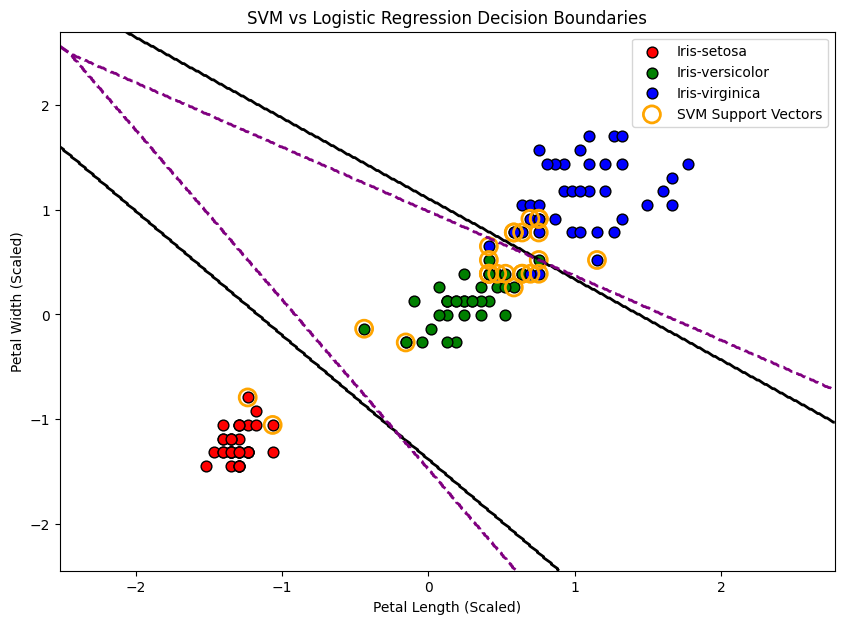

In [18]:
plt.figure(figsize=(10, 7))

# Plot data points
for i, class_name in enumerate(class_names):
    indices = y2_train == class_name

    plt.scatter(
        X2_train_scaled[indices, 0],
        X2_train_scaled[indices, 1],
        color=colors[i],
        label=class_name,
        edgecolor='black',
        s=60
    )

# Plot SVM decision boundaries
plt.contour(
    xx,
    yy,
    Z_svm_num,
    levels=[0.5, 1.5],
    colors='black',
    linewidths=2
)

# Plot Logistic Regression boundaries
plt.contour(
    xx,
    yy,
    Z_lr_num,
    levels=[0.5, 1.5],
    colors='purple',
    linestyles='--',
    linewidths=2
)

# Plot SVM support vectors
plt.scatter(
    svm_2d.support_vectors_[:, 0],
    svm_2d.support_vectors_[:, 1],
    s=150,
    facecolors='none',
    edgecolors='orange',
    linewidths=2,
    label='SVM Support Vectors'
)

plt.xlabel('Petal Length (Scaled)')
plt.ylabel('Petal Width (Scaled)')
plt.title('SVM vs Logistic Regression Decision Boundaries')

plt.legend()
plt.show()


# Task 10: Compare Performance

Compare the performance of the **Linear SVM** and **Logistic Regression** using:

- Accuracy
- Confusion Matrix
- Classification Report

---

In [19]:
# Calculate accuracies
svm_accuracy_2d = accuracy_score(y2_test, y2_pred_svm)
logistic_accuracy_2d = accuracy_score(y2_test, y2_pred_logistic)

print("Performance Comparison")
print("----------------------")

print("Linear SVM Accuracy       : {:.2f}%".format(
    svm_accuracy_2d * 100
))

print("Logistic Regression Accuracy: {:.2f}%".format(
    logistic_accuracy_2d * 100
))


Performance Comparison
----------------------
Linear SVM Accuracy       : 93.33%
Logistic Regression Accuracy: 93.33%


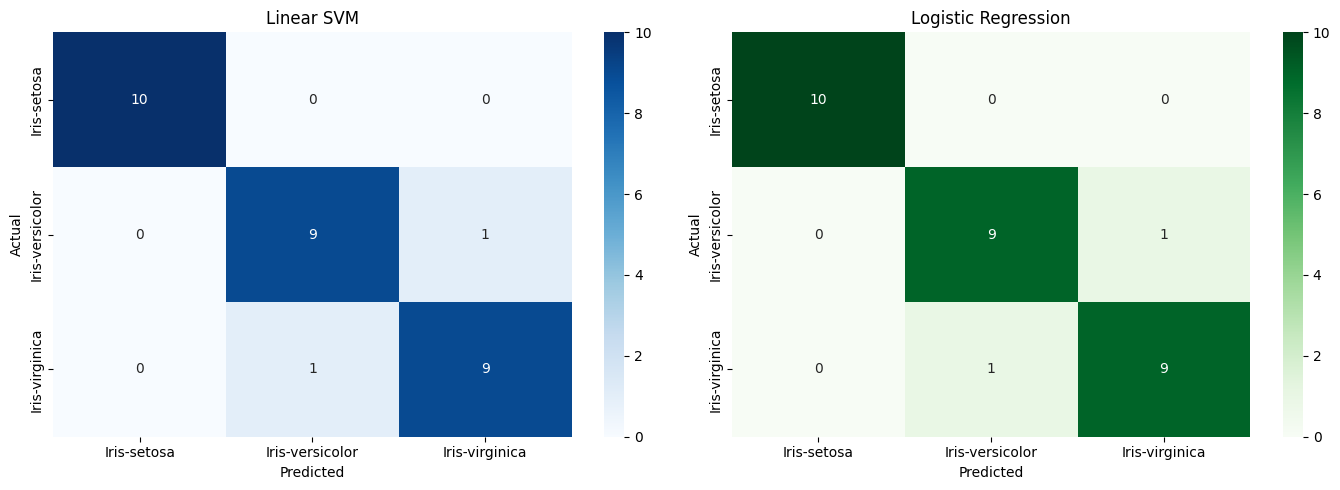

In [20]:
# Confusion matrices
cm_svm_2d = confusion_matrix(y2_test, y2_pred_svm)
cm_logistic = confusion_matrix(y2_test, y2_pred_logistic)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# SVM confusion matrix
sns.heatmap(
    cm_svm_2d,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names,
    ax=axes[0]
)

axes[0].set_title('Linear SVM')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')


# Logistic Regression confusion matrix
sns.heatmap(
    cm_logistic,
    annot=True,
    fmt='d',
    cmap='Greens',
    xticklabels=class_names,
    yticklabels=class_names,
    ax=axes[1]
)

axes[1].set_title('Logistic Regression')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()


In [21]:
print("========== LINEAR SVM ==========")
print(classification_report(y2_test, y2_pred_svm))

print("\n====== LOGISTIC REGRESSION ======")
print(classification_report(y2_test, y2_pred_logistic))


========== LINEAR SVM ==========
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       0.90      0.90      0.90        10
 Iris-virginica       0.90      0.90      0.90        10

       accuracy                           0.93        30
      macro avg       0.93      0.93      0.93        30
   weighted avg       0.93      0.93      0.93        30


====== LOGISTIC REGRESSION ======
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       0.90      0.90      0.90        10
 Iris-virginica       0.90      0.90      0.90        10

       accuracy                           0.93        30
      macro avg       0.93      0.93      0.93        30
   weighted avg       0.93      0.93      0.93        30



In [22]:
# Create performance comparison table
comparison = pd.DataFrame({
    'Classifier': [
        'Linear SVM',
        'Logistic Regression'
    ],
    'Accuracy': [
        svm_accuracy_2d,
        logistic_accuracy_2d
    ]
})

comparison['Accuracy (%)'] = comparison['Accuracy'] * 100

display(comparison)


,Classifier,Accuracy,Accuracy (%)
0,Linear SVM,0.933333,93.333333
1,Logistic Regression,0.933333,93.333333


In [23]:
# RBF SVM
rbf_svm = SVC(
    kernel='rbf',
    random_state=42
)

rbf_svm.fit(X2_train_scaled, y2_train)

y2_pred_rbf = rbf_svm.predict(X2_test_scaled)

rbf_accuracy = accuracy_score(
    y2_test,
    y2_pred_rbf
)

print("RBF SVM Accuracy: {:.2f}%".format(
    rbf_accuracy * 100
))


RBF SVM Accuracy: 93.33%


# Conclusion

The experiment successfully demonstrated the implementation of **Support Vector Machine (SVM)** using the Iris dataset. The dataset was preprocessed and standardized before training the model.

A **Linear SVM** was implemented and its decision boundary was visualized along with the support vectors. A normal linear classification boundary using **Logistic Regression** was also visualized for comparison.